# VEGO GLOBAL Exploratory Data Analysis (EDA):

### Business Intelegence Project:

Our objective is to analyze VEGO GLOBAL's sales, customer, product, and regional data to generate data-driven insights that support sales strategy, marketing, customer understanding, regional performance evaluation, and financial reporting.

**Scope note:** This notebook assumes df (the cleaned, merged Sales / Customers / Product / Geography dataset) is already loaded in the session. Libraries used: pandas, numpy, matplotlib, seaborn only

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Our dataset represents a multinational e-commerce and online retail company operating across several countries and serving a diverse international customer base.
Also the dataset is extracted, clean, merged starting from 4 datasets structured in a star schema format, designed for analytical processing. It included at first one fact table (sales transactions) and multiple dimension tables (customers, products,
sales territories, and currencies).

In [30]:
df = pd.read_csv(r"/home/bouchra/mina/Project/Unified_Sales_Data.csv", low_memory=False)

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

Rows: 362,388 | Columns: 53



We work on a copy of df so the original merged dataframe is not mutated.
VEGO GLOBAL actually manages the business with (Profit, ProfitMargin), calculated columns are created next.

In [106]:
df = df.copy()

df = df.astype({
    "OrderDate": "datetime64[ns]",
    "ShipDate": "datetime64[ns]",
    "BirthDate": "datetime64[ns]",
    "DateFirstPurchase": "datetime64[ns]",
    "DaysToManufacture": "timedelta64[ns]",
    "StartDate": "datetime64[ns]",
    "Gender": "category",
    "MaritalStatus": "category",
    "FinishedGoodsFlag": "bool",
    "HouseOwnerFlag": "bool",
})
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 362388 entries, 0 to 362387
Data columns (total 60 columns):
 #   Column                 Non-Null Count   Dtype          
---  ------                 --------------   -----          
 0   ProductKey             362388 non-null  int64          
 1   OrderDate              362388 non-null  datetime64[ns] 
 2   ShipDate               362388 non-null  datetime64[ns] 
 3   CustomerKey            362388 non-null  int64          
 4   PromotionKey           362388 non-null  int64          
 5   SalesTerritoryKey      362388 non-null  int64          
 6   SalesOrderNumber       362388 non-null  str            
 7   SalesOrderLineNumber   362388 non-null  int64          
 8   UnitPrice              362388 non-null  float64        
 9   ExtendedAmount         362388 non-null  float64        
 10  ProductStandardCost    362388 non-null  float64        
 11  TotalProductCost       362388 non-null  float64        
 12  CurrencyKey            362388 non-null  s

In [32]:
df["Profit"] = df["SalesAmount"] - df["TotalProductCost"]
df["ProfitMargin"] = np.where(
    df["SalesAmount"] != 0,
    (df["Profit"] / df["SalesAmount"]) * 100,
    np.nan
)

extracting useful time information from OrderDate and putting each piece into a new column (creating derived variables).

In [33]:
df["OrderYear"] = df["OrderDate"].dt.year
df["OrderMonth"] = df["OrderDate"].dt.month
df["OrderQuarter"] = df["OrderDate"].dt.quarter
df["OrderMonthName"] = df["OrderDate"].dt.strftime("%b")

df[["SalesAmount", "TotalProductCost", "Profit", "ProfitMargin",
    "OrderDate", "OrderYear", "OrderMonth", "OrderQuarter"]].head()

,SalesAmount,TotalProductCost,Profit,ProfitMargin,OrderDate,OrderYear,OrderMonth,OrderQuarter
0,3578.2700,2171.2942,1406.9758,39.320001,2010-12-29,2010,12,4
1,3399.9900,1912.1544,1487.8356,43.759999,2010-12-29,2010,12,4
2,3399.9900,1912.1544,1487.8356,43.759999,2010-12-29,2010,12,4
3,699.0982,413.1463,285.9519,40.902966,2010-12-29,2010,12,4
4,3399.9900,1912.1544,1487.8356,43.759999,2010-12-29,2010,12,4


# 1. Overall Business Performance: 

## Measured Cards:

In [34]:
print(f"Data covers: {df['OrderDate'].min().date()} to {df['OrderDate'].max().date()}")

total_sales = df["SalesAmount"].sum()
total_cost = df["TotalProductCost"].sum()
total_profit = df["Profit"].sum()
overall_margin = (total_profit / total_sales) * 100

n_orders = df["SalesOrderNumber"].nunique()
n_customers = df["CustomerKey"].nunique()
n_products = df["ProductKey"].nunique()

summary = pd.Series({
    "Total Sales ($)": total_sales,
    "Total Cost ($)": total_cost,
    "Total Profit ($)": total_profit,
    "Overall Profit Margin (%)": overall_margin,
    "Number of Orders": n_orders,
    "Number of Customers": n_customers,
    "Number of Products Sold": n_products,
})
for name, value in summary.items():
    print(f"{name:<20} {value}")

Data covers: 2010-12-29 to 2014-01-28
Total Sales ($)      176152063.32419997
Total Cost ($)       103666761.4542
Total Profit ($)     72485301.87
Overall Profit Margin (%) 41.14927778994792
Number of Orders     27659.0
Number of Customers  18484.0
Number of Products Sold 158.0


## Overview Visuals:

/tmp/ipykernel_7027/682257689.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([f"${y/1e6:,.0f}M" for y in ax.get_yticks()])


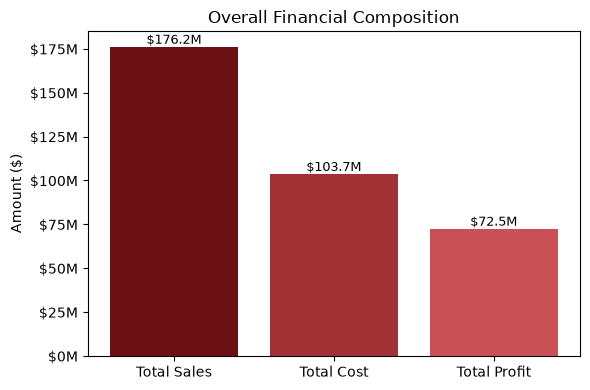

In [111]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["Total Sales", "Total Cost", "Total Profit"],
    [total_sales, total_cost, total_profit],
    color=["#6B1114", "#A03235", "#C95055"]
)
ax.set_title( "Overall Financial Composition")
ax.set_ylabel("Amount ($)")
ax.set_yticklabels([f"${y/1e6:,.0f}M" for y in ax.get_yticks()])
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"${b.get_height()/1e6:,.1f}M",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

/tmp/ipykernel_7027/3309002560.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([f"${y/1e6:,.0f}M" for y in ax.get_yticks()])


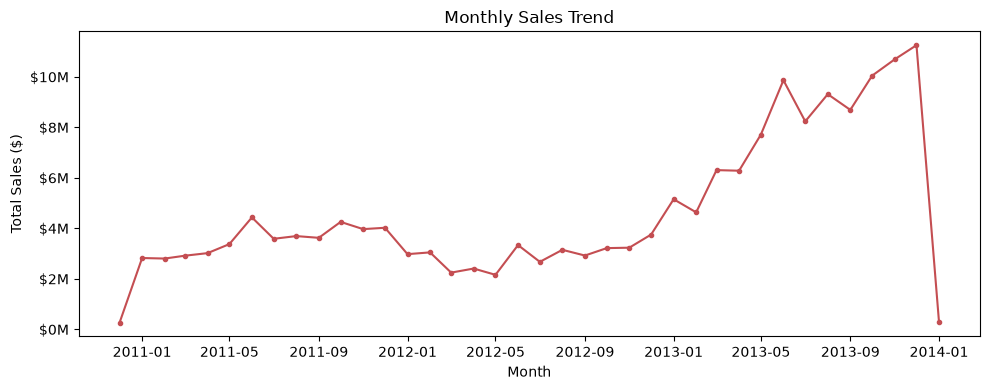

In [105]:
monthly_sales = df.groupby(df["OrderDate"].dt.to_period("M"))["SalesAmount"].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_sales.index, monthly_sales.values, marker="o", markersize=3, color="#C44E52")
ax.set_title("Monthly Sales Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales ($)")
ax.set_yticklabels([f"${y/1e6:,.0f}M" for y in ax.get_yticks()])
plt.tight_layout()
plt.show()


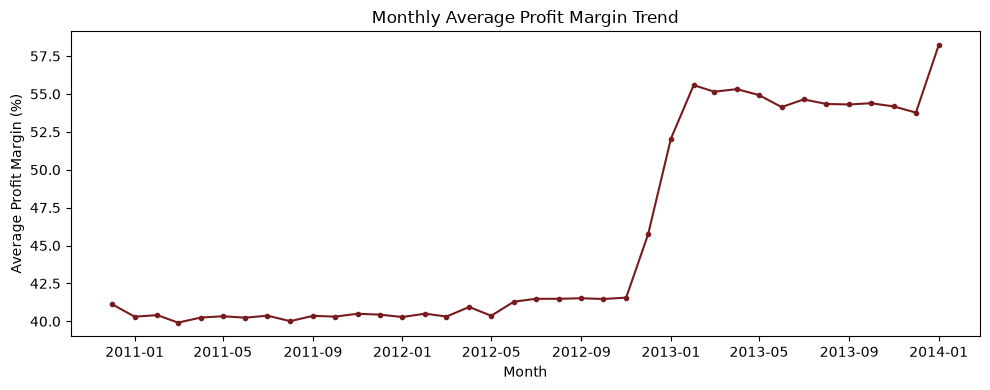

In [37]:
monthly_margin = df.groupby(df["OrderDate"].dt.to_period("M"))["ProfitMargin"].mean()
monthly_margin.index = monthly_margin.index.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_margin.index, monthly_margin.values, marker="o", markersize=3, color="#781B1E")
ax.set_title("Monthly Average Profit Margin Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Average Profit Margin (%)")
plt.tight_layout()
plt.show()

In [38]:
print(f"Mean SalesAmount: ${df['SalesAmount'].mean():,.2f} | Median: ${df['SalesAmount'].median():,.2f}")

Mean SalesAmount: $486.09 | Median: $29.99


# 2. Performance Insights:

## Consumers insight:

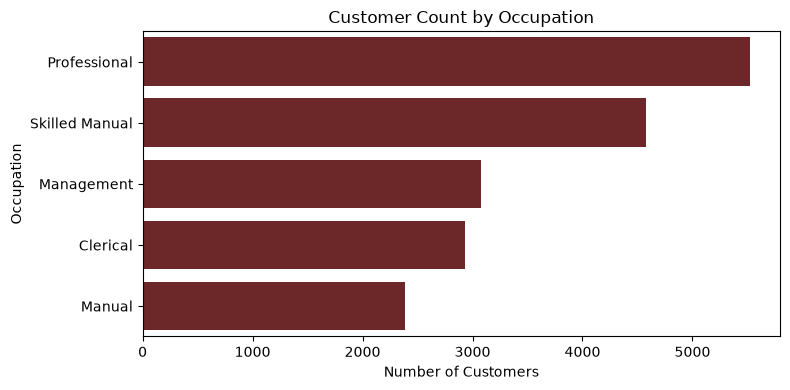

In [39]:
order_level = df.drop_duplicates(subset="CustomerKey")
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(
    data=order_level, y="EnglishOccupation",
    order=order_level["EnglishOccupation"].value_counts().index,
    color="#781B1E", ax=ax
)
ax.set_title("Customer Count by Occupation")
ax.set_xlabel("Number of Customers")
ax.set_ylabel("Occupation")
plt.tight_layout()
plt.show()

In [64]:
occupation_summary = group_summary(df, "EnglishOccupation")
occupation_summary

,TotalSales,TotalProfit,AvgProfitMargin,Orders,Customers
EnglishOccupation,,,,,
Professional,5.944786e+07,2.459741e+07,53.443412,8661,5520
Skilled Manual,3.864049e+07,1.584314e+07,53.557087,6599,4577
Management,3.280717e+07,1.356201e+07,53.956055,4819,3075
Clerical,2.810872e+07,1.146262e+07,52.332838,4398,2928
Manual,1.714783e+07,7.020123e+06,53.168072,3182,2384


**Insight:** Professionals and Skilled Manuals are VEGO GLOBAL's largest customer occupation segments.These two groups anchor the core customer base and should be prioritized in messaging and loyalty programs.

In [41]:
def group_summary(data, group_col, top_n=None):
    summary = (
        data.groupby(group_col)
        .agg(
            TotalSales=("SalesAmount", "sum"),
            TotalProfit=("Profit", "sum"),
            AvgProfitMargin=("ProfitMargin", "mean"),
            Orders=("SalesOrderNumber", "nunique"),
            Customers=("CustomerKey", "nunique"),
        )
        .sort_values("TotalSales", ascending=False)
    )
    return summary.head(top_n) if top_n else summary

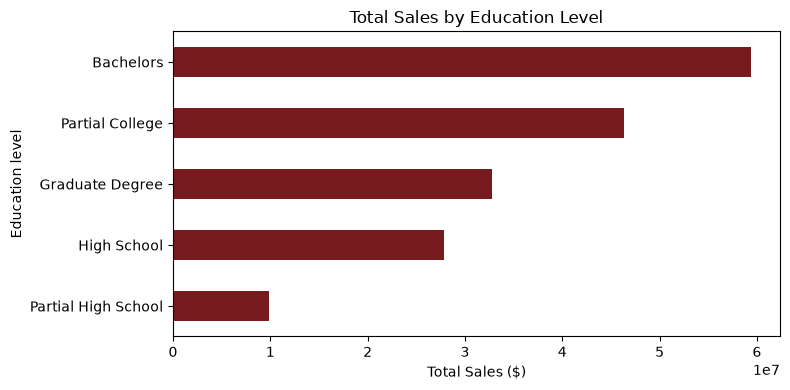

In [42]:
sales_by_occupation = (
    df.groupby("EnglishEducation")["SalesAmount"]
      .sum()
      .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 4))

sales_by_occupation.plot(kind="barh", ax=ax, color="#781B1E")
ax.set_title("Total Sales by Education Level")
ax.set_xlabel("Total Sales ($)")
ax.set_ylabel("Education level")

plt.tight_layout()
plt.show()

In [45]:
occupation_summary = group_summary(df, "EnglishEducation")
occupation_summary


,TotalSales,TotalProfit,AvgProfitMargin,Orders,Customers
EnglishEducation,,,,,
Bachelors,5.940086e+07,2.438889e+07,52.562111,8408,5356
Partial College,4.634126e+07,1.912082e+07,53.442154,7508,5064
Graduate Degree,3.276336e+07,1.351660e+07,53.248787,4836,3189
High School,2.782816e+07,1.137914e+07,53.804669,4771,3294
Partial High School,9.818432e+06,4.079851e+06,55.313445,2136,1581


**Insight:** Partial High Schoolers and Bachelors are VEGO GLOBAL's largest customer Education segments.
Partial High Schoolers are classing first, they exceeds other Educationalsegments in terms of Total sales and profit, and Average profit margin, other segments being close in sales and profits also in average profit margin. However, most orders are driven by Bachelors, Bachelors and Parcial college attenders also compose the largest consumers dymographics dominating over 50% of the company's buyers segment.

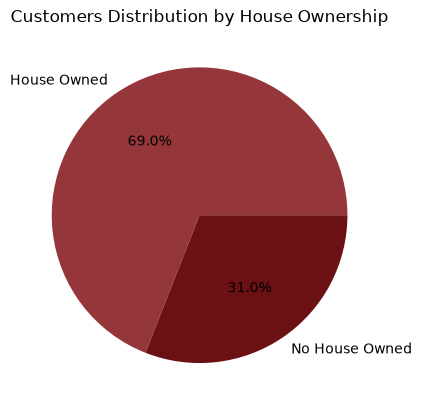

In [95]:
sex_counts = df["HouseOwnerFlag"].value_counts()

fig, ax = plt.subplots()

ax.pie(
    sex_counts.values,
    labels = sex_counts.index.map({
    False : "No House Owned",
    True : "House Owned"
    }),
    autopct="%1.1f%%",
    colors=["#95373A", "#6B1114"]
)

ax.set_title("Customers Distribution by House Ownership")

plt.show()


**insights:** Clearly, House Owners are the largest segment of VEGO GLOBAL's Consumers.

In [65]:
occupation_summary = group_summary(df, "NumberChildrenAtHome")
occupation_summary

,TotalSales,TotalProfit,AvgProfitMargin,Orders,Customers
NumberChildrenAtHome,,,,,
0,1.075578e+08,4.414008e+07,53.109285,16433,11116
1,2.123538e+07,8.732844e+06,53.424425,3505,2460
2,1.774135e+07,7.303249e+06,52.200984,2407,1648
5,1.125986e+07,4.610526e+06,53.430998,1668,967
4,9.562905e+06,4.008000e+06,54.933616,1874,1089
3,8.794765e+06,3.690603e+06,55.149131,1772,1204


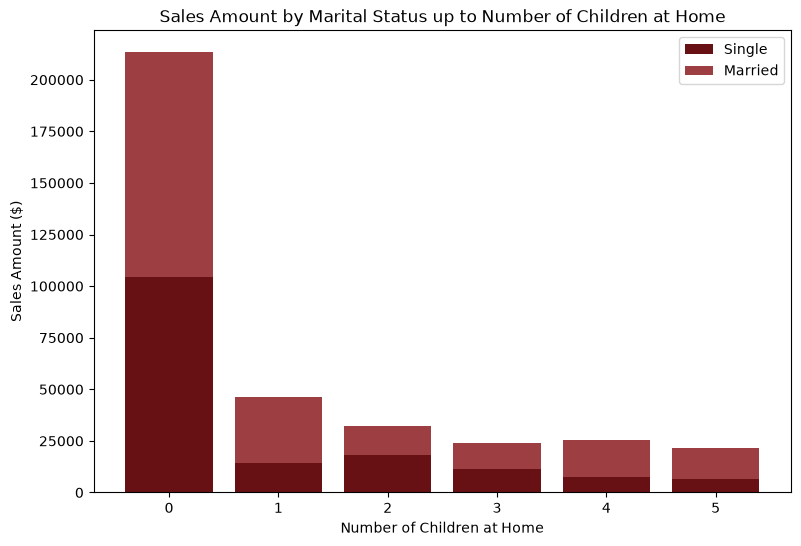

In [91]:
stacked = pd.crosstab(df["NumberChildrenAtHome"], df["MaritalStatus"])

fig, ax = plt.subplots(figsize=(9, 6))

stacked.columns = stacked.columns.astype(str)

S = "S"
M = "M"
ax.bar(stacked.index.astype(str), stacked[S], label="Single", color="#681114")

ax.bar(
    stacked.index.astype(str),
    stacked[M],
    bottom=stacked[S],
    label="Married",
    color="#9D3F42"
)

ax.set_title("Sales Amount by Marital Status up to Number of Children at Home")
ax.set_xlabel("Number of Children at Home")
ax.set_ylabel("Sales Amount ($)")

ax.legend()

plt.show()

**Note & Insights:** Single section composed of singles, devorced and widowed, meaning all consumers not living in partnership, for that single section shows children arround the house.
Most of VEGO GLOBAL's sales are driven from consumers that are not paranting kids, Married consumers with either 0, 1 or 4 kids are more valuable then those with 3, 4 or 5 kids.

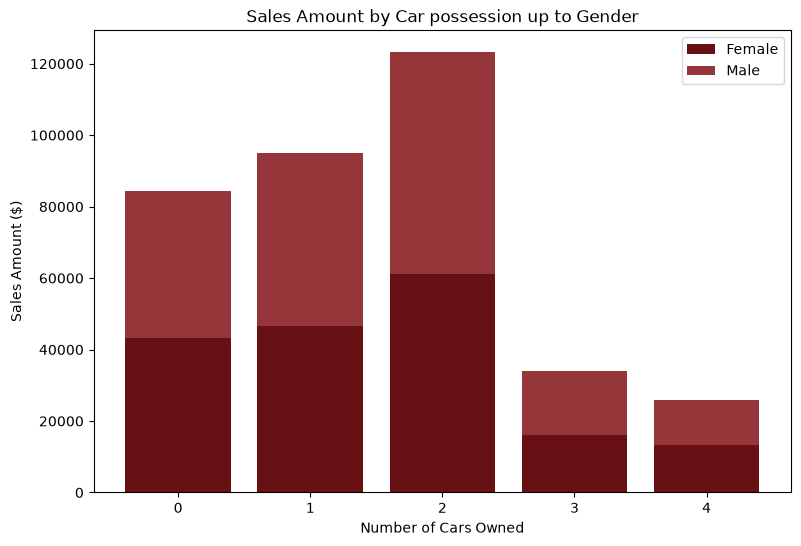

In [98]:
stacked = pd.crosstab(df["Gender"], df["NumberCarsOwned"])

fig, ax = plt.subplots(figsize=(9, 6))
stacked.columns = stacked.columns.astype(str)

F = "F"
M = "M"

stacked = stacked.T
ax.bar(stacked.index.astype(str), stacked[F], label="Female", color="#681114")

ax.bar(
    stacked.index.astype(str),
    stacked[M],
    bottom=stacked[F],
    label="Male",
    color="#95373A"
)

ax.set_title("Sales Amount by Car possession up to Gender")
ax.set_xlabel("Number of Cars Owned")
ax.set_ylabel("Sales Amount ($)")

ax.legend()

plt.show()

**Insight:** The visual shows that Gender doesn,t effect Sales. Consumers owning 3 or 4 cars are the least onces driving sales, the most valuable segment of consumers is the one made of those who own 2 cars.

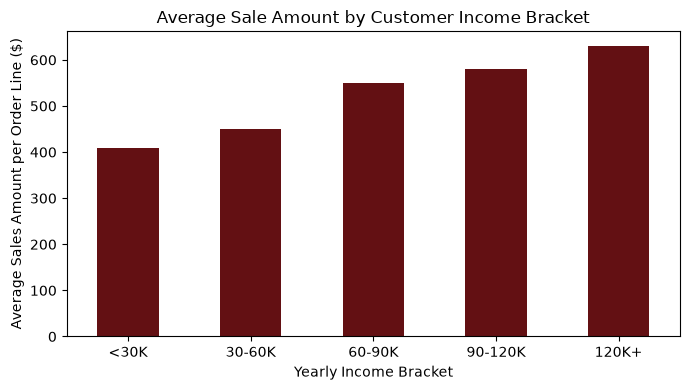

In [49]:
income_bins = pd.cut(df["YearlyIncome"], bins=[0, 30000, 60000, 90000, 120000, 200000],
                      labels=["<30K", "30-60K", "60-90K", "90-120K", "120K+"])
income_sales = df.groupby(income_bins, observed=True)["SalesAmount"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
income_sales.plot(kind="bar", color="#631013", ax=ax)
ax.set_title("Average Sale Amount by Customer Income Bracket")
ax.set_xlabel("Yearly Income Bracket")
ax.set_ylabel("Average Sales Amount per Order Line ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** VEGO GLOBAL's higher-income customers are not necessarily buying higher-value items per line, though they may still buy more frequently (not tested here).


## Product Performance:

In [50]:
productline_summary = group_summary(df, "ProductLine")
productline_summary

,TotalSales,TotalProfit,AvgProfitMargin,Orders,Customers
ProductLine,,,,,
R,8.774465e+07,3.361263e+07,49.678520,11787,9557
M,6.150710e+07,2.820262e+07,57.552665,11311,9589
T,2.327599e+07,8.858933e+06,50.910186,3493,3386
S,3.624320e+06,1.811111e+06,53.237846,17224,14423


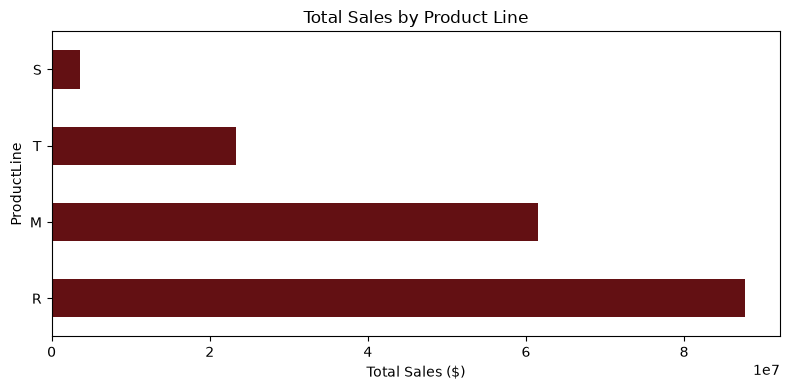

In [52]:
def plot_bar(summary_df, column, title, ylabel, color):
	fig, ax = plt.subplots(figsize=(8, 4))
	summary_df[column].plot(kind="barh", ax=ax, color=color)
	ax.set_title(title)
	ax.set_xlabel(ylabel)
	plt.tight_layout()
	plt.show()

plot_bar(productline_summary, "TotalSales", "Total Sales by Product Line", "Total Sales ($)", color="#6"31013)


**Insight:** Road bikes (R) generate the most total sales and ~50% average profit margine , but Mountain bikes (M) deliver a  higher average profit margin ~58% even if thier sales are declined.

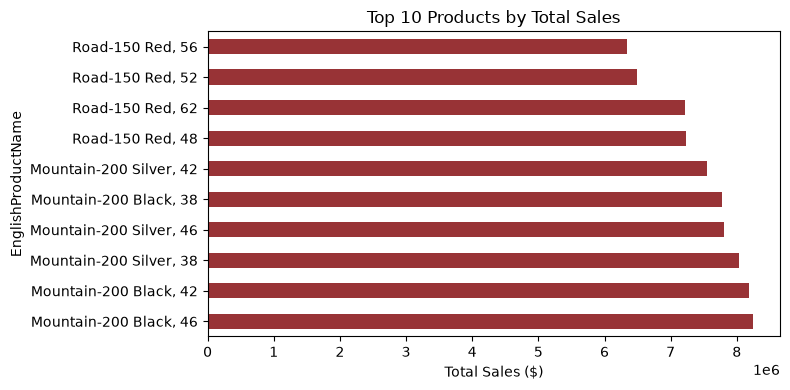

In [55]:
top_products = group_summary(df, "EnglishProductName", top_n=10)
plot_bar(top_products, "TotalSales", "Top 10 Products by Total Sales", "Total Sales ($)", color="#983336")


**Insight:** the top 10 products are Mountain-200 and Road-150 model variants a small set of SKUs driving a large share of revenue, that is signal for inventory and marketing prioritization.

## Promotion Flag:

In [56]:
df["PromoFlag"] = np.where(df["PromotionKey"] == 1, "No Promotion", "Promotional")
promo_summary = group_summary(df, "PromoFlag")
promo_summary

,TotalSales,TotalProfit,AvgProfitMargin,Orders,Customers
PromoFlag,,,,,
No Promotion,1.638456e+08,6.723526e+07,53.445637,27119,18405
Promotional,1.230642e+07,5.250046e+06,50.806437,2104,2016


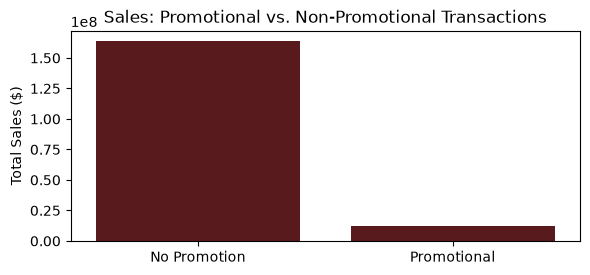

In [61]:
fig, ax = plt.subplots(figsize=(6, 3))

sns.barplot(
    data=promo_summary,
    x=promo_summary.index,
    y="TotalSales",
    color="#631013",
    ax=ax
)
ax.set_title("Sales: Promotional vs. Non-Promotional Transactions")
ax.set_xlabel("")
ax.set_ylabel("Total Sales ($)")

plt.tight_layout()
plt.show()

**Note & Insight:** PromotionKey = 1 is the baseline "No Promotion", but since it covers ~96% of transactions and shows no price discount versus list price; the rest of numbers (or codes) 2/13/14 are all used as Promotional. this reading showed that the majority of VEGO GLOBAL's sales occur without an active promotion, and the small promotional segment shows a slightly lower average margin, we can tell that promotions are not  a large or active or even margin-accretive lever.

## Regional Performance:

In [66]:
country_summary = group_summary(df, "SalesTerritoryCountry")
country_summary

,TotalSales,TotalProfit,AvgProfitMargin,Orders,Customers
SalesTerritoryCountry,,,,,
United States,5.633874e+07,2.340588e+07,54.063742,9567,7819
Australia,5.436600e+07,2.211513e+07,51.538430,6718,3591
United Kingdom,2.035027e+07,8.342945e+06,52.515019,3031,1913
Germany,1.736587e+07,7.124225e+06,52.200135,2484,1780
France,1.586411e+07,6.517588e+06,52.928804,2484,1810
Canada,1.186707e+07,4.979529e+06,56.449212,3375,1571


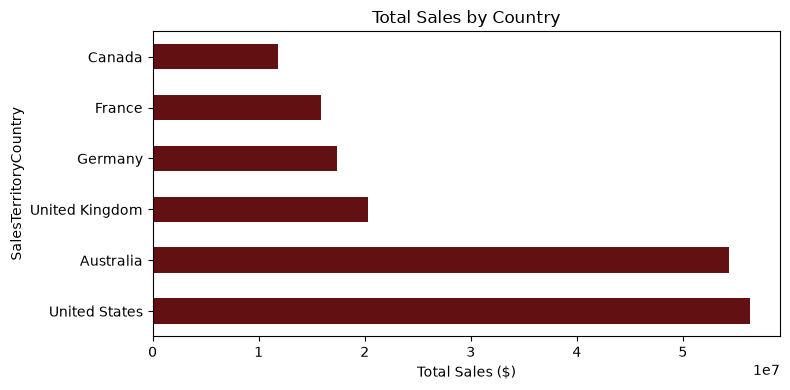

In [67]:
plot_bar(country_summary, "TotalSales", "Total Sales by Country", "Total Sales ($)")

**Insight:** United Stats of America is driving most sales and hight profit, taking place as top selling country. followed by Austrelia that drives second best sales 5.4M$, yet with a lower Average Profit Margin comparing to United Kingdom, Germany and France that are classing 3rd, 4th and 5th Successively. Canda, on the other hand is classing 6th with 1.1M$ sales in a year yet it is pointing the highest average profit margin with 56.4%

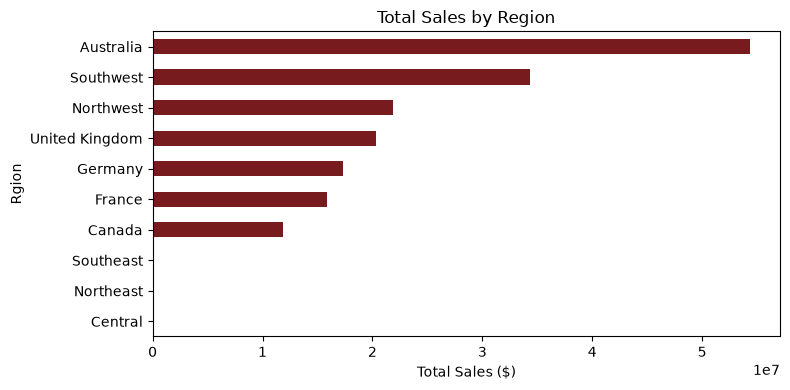

In [75]:
sales_by_group = (
    df.groupby("SalesTerritoryRegion")["SalesAmount"]
      .sum()
      .sort_values()
)
fig, ax = plt.subplots(figsize=(8, 4))

sales_by_group.plot(kind="barh", ax=ax, color="#781B1E")
ax.set_title("Total Sales by Region")
ax.set_xlabel("Total Sales ($)")
ax.set_ylabel("Rgion")

plt.tight_layout()
plt.show()

In [86]:
country_summary = group_summary(df, "SalesTerritoryRegion")
country_summary

,TotalSales,TotalProfit,AvgProfitMargin,Orders,Customers
SalesTerritoryRegion,,,,,
Australia,5.436600e+07,2.211513e+07,51.538430,6718,3591
Southwest,3.430890e+07,1.423058e+07,53.801489,5473,4450
Northwest,2.189920e+07,9.117788e+06,54.406665,4058,3341
United Kingdom,2.035027e+07,8.342945e+06,52.515019,3031,1913
Germany,1.736587e+07,7.124225e+06,52.200135,2484,1780
France,1.586411e+07,6.517588e+06,52.928804,2484,1810
Canada,1.186707e+07,4.979529e+06,56.449212,3375,1571
Southeast,7.343310e+04,3.199456e+04,53.873945,17,12
Northeast,3.919481e+04,1.741657e+04,57.445593,10,8


**insight:** with the United Stats broken to 5 regional areas (Northwest, Northeast, Southwest, Southeast and Center) and compared to other geographic regions, both west areas (Northwest and Southwest) are driving higher Sales and Profits, yet Northeast and Center exceeds them in terms of average profit margine with 57% and 56% Successively.

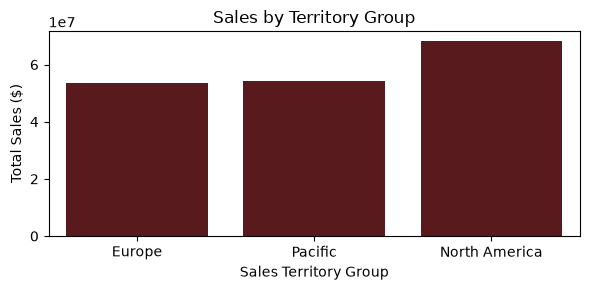

In [74]:
fig, ax = plt.subplots(figsize=(6, 3))

sales_group_df = sales_by_group.reset_index()
sales_group_df.columns = ["SalesTerritoryGroup", "TotalSales"]

sns.barplot(
    data=sales_group_df,
    x="SalesTerritoryGroup",
    y="TotalSales",
    color="#631013",
    ax=ax
)
ax.set_title("Sales by Territory Group")
ax.set_xlabel("Sales Territory Group")
ax.set_ylabel("Total Sales ($)")

plt.tight_layout()
plt.show()

In [87]:
country_summary = group_summary(df, "SalesTerritoryGroup")
country_summary

,TotalSales,TotalProfit,AvgProfitMargin,Orders,Customers
SalesTerritoryGroup,,,,,
North America,6.820581e+07,2.838541e+07,54.691324,12942,9390
Pacific,5.436600e+07,2.211513e+07,51.538430,6718,3591
Europe,5.358025e+07,2.198476e+07,52.544241,7999,5503


**insight:** Clearly, North American Group of Countries exceeds both Europian and Pacific groups in all terms (higher sales, profits and average profit margine), it is the geographic group the most valuable for VEGO Global company. 

### General Insights

. VEGO GLOBAL generated $176.2M in total sales and $72.5M in profit over the observed period, at a 41.1% overall margin.

. The **United States and Australia** are co-leading markets and contributing 63% of total sales.

. **North America** is the top-performing sales group ahead of Pacific and Europe.

. **Road bikes** lead in total sales, but **Mountain bikes** lead in profit margin volume.

. **Promotions cover only 4% of transactions** and show no clear margin advantage over non-promotional sales.

. **Customer income** is less important factor when targeting consumers

# 3. Relationships Explore:

### Correlation:

We look at **correlations** and patterns that might help explain differences in sales and profitability. Correlation does not imply\Prove causality yet it intreduces directional signals for further investigation.

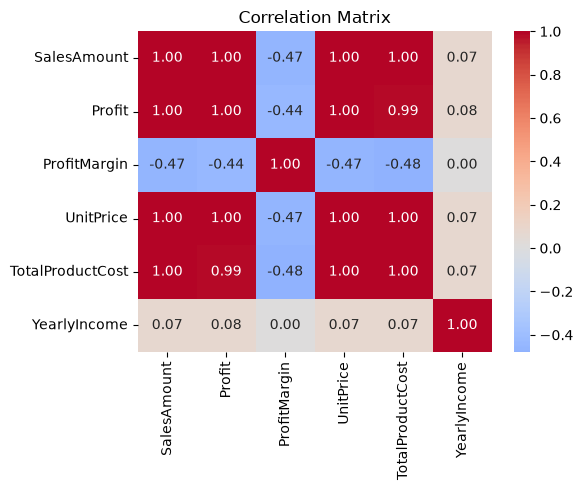

In [112]:
corr_cols = ["SalesAmount", "Profit", "ProfitMargin", "UnitPrice", "TotalProductCost", "YearlyIncome"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

**Insight:**
- `SalesAmount`, `UnitPrice`, and `TotalProductCost` move together most of the time
   r≈1.0, this is expected, since each order line in this dataset is in terms of
  units, so price and revenue correlate, and cost scales tightly with price.
- `ProfitMargin` is *negatively* correlated with `SalesAmount` r≈-0.47 meaning more
  expensive items tend to carry a *lower percentage* margin, even though they
  generate more absolute profit.
- `YearlyIncome` has a very weak correlation with `SalesAmount` r≈0.07
  customer income alone is a poor predictor of how much a customer spends per
  order line.
- `ProfitMargin` is *negatively* correlated with `TotalProductCost` r≈-0.48, expected, yet the thing 
  that is not expected is the negative correlation between `Profit` and `ProfitMargin` r≈-0.44, one hypothisis can be tht products generate a large absolute profit because many units are sold, while each unit has a relatively small margin.

### Time Analysis:

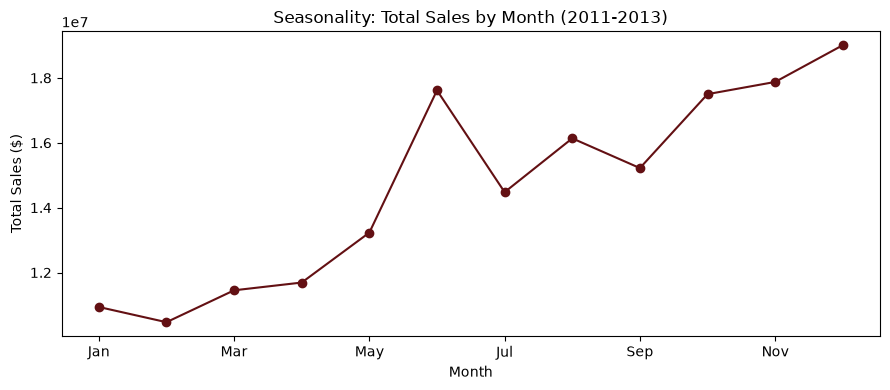

In [101]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
seasonal = df[~df["OrderYear"].isin([2010, 2014])]
monthly_avg = seasonal.groupby("OrderMonthName")["SalesAmount"].sum().reindex(month_order)

fig, ax = plt.subplots(figsize=(9, 4))
monthly_avg.plot(kind="line", marker="o", color="#631013", ax=ax)
ax.set_title("Seasonality: Total Sales by Month (2011-2013)")
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

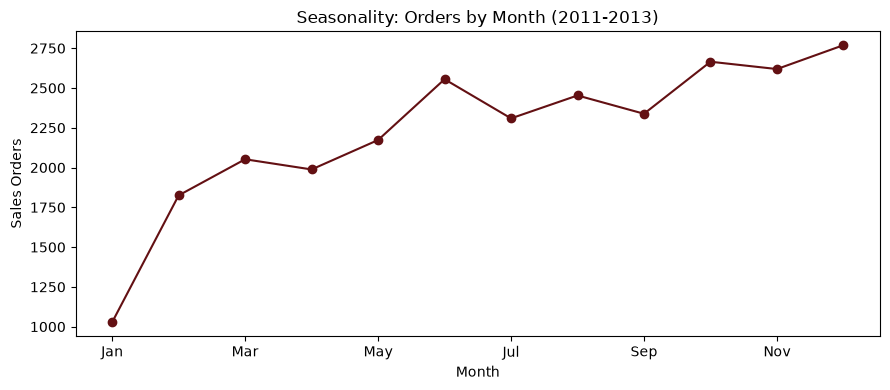

In [103]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
seasonal = df[~df["OrderYear"].isin([2010, 2014])]
monthly_avg = (
	seasonal.groupby("OrderMonthName")["SalesOrderNumber"]
	.nunique()
	.reindex(month_order)
)

fig, ax = plt.subplots(figsize=(9, 4))
monthly_avg.plot(kind="line", marker="o", color="#631013", ax=ax)
ax.set_title("Seasonality: Orders by Month (2011-2013)")
ax.set_xlabel("Month")
ax.set_ylabel("Sales Orders")
plt.tight_layout()
plt.show()

**Note & Insight:** The year 2014 is excluded becease its observations are not comleted coming to the last quarter, this can effect the time series analysis.
sales Grow monotonically through the year with an a faster growth during the 4th quarter Q4
(Oct-Dec), and a secondary peak in June, this seasonal pattern can be used as a sales banchmark and should be studies and enphesised. 

# 4. Hypotheses & Results:

Based on the results above, the following business hypotheses are posed:

**1. Uneven Regional Performance**
- Revenues are heavily concentrated in the US, then Australia, Canada and the UK/Germany/France Countries, leaving VEGO GLOBAL exposed if the native market falls. over reliance on one local markets increases exposure to local economic or competitive shocks.

**2. Higher-value items carry structurally lower percentage margins**
- VEGO GLOBAL's pricing structure yields lower percentage margins on higher-priced products, even though absolute profit per unit is higher. pricing policy that is not per transaction negotiation is the real lever for improving overall margin.

**3. Promotions do not drive major or clear benefits levels**
- Promotional transactions do not outperform non promotional ones on margin, and represent a very small share of overall sales. Around 96% of transactions had no promotion; the small promotional segment shows a similar or lower average margin than the non promotional baseline. If promotions are not lifting sales or margin, marketing spend on them should be reassessed or redesigned.

**6. Customer income is a weak predictor of order value**
- Yearly income does not explain how much a customer spends per order line. The correlation between `YearlyIncome` and `SalesAmount` is very weak (≈0.07); average sale amount is roughly flat across income brackets. Income based targeting or marketing will not be effective to predict or grow order value; other factors (occupation, product interest, region) may matter more.

**7. Sales have a clear seasonal demand**
- VEGO GLOBAL experiences a recurring seasonal sales peak in Q4, with a secondary mid-year peak. Q4 sales ($54.6M) are the highest, and the month by month view shows a steady rise until December also a June spike.Marketing campaigns can be timed to capture peak seasonal demand more effectively.

# 5. Recommended Business Actions

1. **Diversify regional exposure:** invest in growing mid-tier and underperforming markets (e.g., Canada, Southeast/Northeast/Central regions) to reduce reliance on the US/Australia concentration.
2. **Rebalance product marketing toward margin:** shift a portion of promotional/marketing spend from high-volume Road bikes toward higher-margin Mountain bikes to lift overall profitability.
3. **Protect top-SKU availability:** tighten inventory planning (safety stock, reorder points) specifically around the top 10 revenue-driving product variants.
4. **Reassess promotion strategy:** redesign or retarget promotions, since the current promotional segment shows no clear margin or scale benefit over regular sales.
5. **Align operations to seasonality:** plan inventory build-up, staffing, and marketing pushes ahead of the Q4 peak and the secondary June uptick to maximize seasonal demand capture.
